Image shape:  (895, 1192, 3)
Image Dtype:  uint8
Gray image shape:  (895, 1192)
Gray image dtype:  uint8


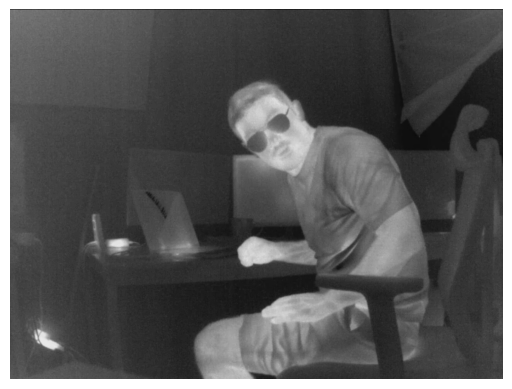

In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img_path = "images/thermal_image_2.png"
img = cv2.imread(img_path)
if img is None:
    print("Image not found")

print("Image shape: ", img.shape)
print("Image Dtype: ", img.dtype)

gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Gray image shape: ", gray_image.shape)
print("Gray image dtype: ", gray_image.dtype)

plt.imshow(gray_image, vmin=0, vmax=255, cmap="gray")
plt.axis("off")
plt.show()

In [14]:
# thresholding

threshold_value = 127

ret, binary = cv2.threshold(
    gray_image,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

print("Ret(which is the threshold provided or calculated): ", ret)

cv2.imwrite("outputs/masking/thresholded.png", binary)

# inversing binary

ret, binary = cv2.threshold(
    gray_image,
    threshold_value,
    255,
    cv2.THRESH_BINARY_INV
)

cv2.imwrite("outputs/masking/inverted_thresholded.png", binary)

Ret(which is the threshold provided or calculated):  127.0


True

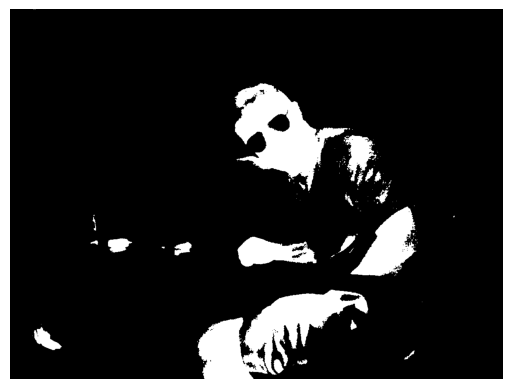

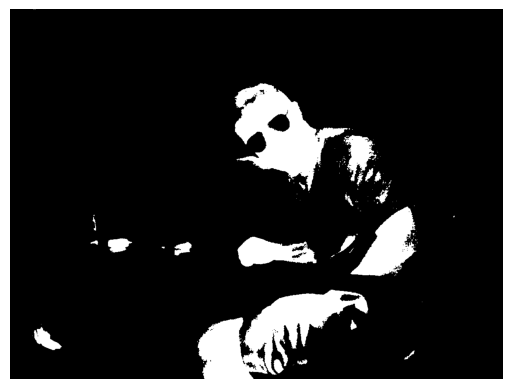

Max diff:  0


In [21]:
# threshold with numpy

np_binary = gray_image.copy()
np_binary[gray_image > 127] = 255
np_binary[gray_image <= 127] = 0

plt.imshow(np_binary, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

np_binary_2 = np.where(gray_image > 127, 255, 0)
plt.imshow(np_binary_2, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

# compare with cv2 method
ret, binary = cv2.threshold(
    gray_image,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

difference = cv2.absdiff(np_binary, binary)
max_diff = difference.max()
print("Max diff: ", max_diff)

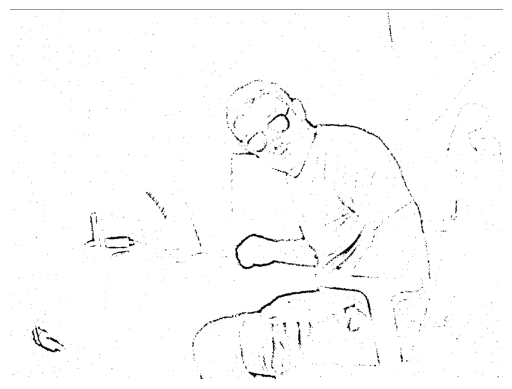

In [50]:
# adaptive thresholding

adaptive = cv2.adaptiveThreshold(
    gray_image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    21, # blockSize is the local neighborhood size - personal obs: makes borders bolder
    10 # C is a value subtracted from the local threshold - personal obs: makes image "cleaner (less borders detected)"
)

cv2.imwrite("outputs/masking/adaptive_threshold.png", adaptive)

plt.imshow(adaptive, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

In [47]:
# otsu thresholding
# OpenCV analyzes the image histogram and chooses a threshold.

ret, otsu = cv2.threshold(
    gray_image,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu threshold: ", ret)
cv2.imwrite("outputs/masking/otsu_threshold.png", otsu)



Otsu threshold:  97.0


True

In [51]:
# blur before thresholing

blur_img = cv2.GaussianBlur(gray_image, (5, 5), 0)

ret, binary = cv2.threshold(
    blur_img,
    127,
    255,
    cv2.THRESH_BINARY
)

cv2.imwrite("outputs/masking/threshold_after_blur.png", binary)

True

In [52]:
# masking

img_masked = cv2.bitwise_and(gray_image, gray_image, mask=binary)

cv2.imwrite("outputs/masking/masked.png", img_masked)

True

In [ ]:
# A very common future pipeline will be: image → grayscale/HSV → threshold/mask → clean mask → contours → bounding boxes